#**DATA GEMPA**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

url = "/content/gempa_2020.csv"
df = pd.read_csv(url)

df

,Year,Month,Day,Time,Lat,Lon,Depth,Mag,Region,Timestamp
0,2020,12,30,23:03:00,5.1231,125.2581,54.1,4.6,"38 km SW of Sarangani, Philippines",1609369380
1,2020,12,30,21:27:32,7.6359,126.9172,53.3,4.6,"40 km E of Baganga, Philippines",1609363652
2,2020,12,30,20:29:33,-6.6907,127.4441,393.4,4.5,"208 km NNE of Lospalos, Timor Leste",1609360173
3,2020,12,30,19:36:05,-6.8738,147.6965,68.4,4.5,"38 km SSW of Finschhafen, Papua New Guinea",1609356965
4,2020,12,30,19:10:20,-2.3988,127.4859,16.4,4.8,"163 km NNW of Ambon, Indonesia",1609355420
...,...,...,...,...,...,...,...,...,...,...
4044,2020,1,1,12:28:34,0.1936,121.5572,141.3,4.1,"38km S of Lemito, Indonesia",1577881714
4045,2020,1,1,06:01:14,-6.7009,129.7667,155.1,4.4,"219km NW of Saumlaki, Indonesia",1577858474
4046,2020,1,1,04:38:07,2.0047,126.7211,51.0,4.4,"146km WNW of Tobelo, Indonesia",1577853487
4047,2020,1,1,00:35:48,-5.3373,152.6003,32.9,4.6,"107km SSW of Taron, Papua New Guinea",1577838948


#**CLEANING DATA**

In [ ]:
df.isna().sum() #cek nan

,0
Year,0
Month,0
Day,0
Time,0
Lat,0
Lon,0
Depth,0
Mag,0
Region,0
Timestamp,0


In [ ]:
df.dtypes #cek type data

,0
Year,int64
Month,int64
Day,int64
Time,object
Lat,float64
Lon,float64
Depth,float64
Mag,float64
Region,object
Timestamp,int64


In [ ]:
df.columns #cek kolom

Index(['Year', 'Month', 'Day', 'Time', 'Lat', 'Lon', 'Depth', 'Mag', 'Region',
       'Timestamp'],
      dtype='object')

In [ ]:
# Pastikan kolom 'Time' dalam format datetime
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

# Menghapus tanggal, hanya menyisakan waktu
df['Time'] = df['Time'].dt.time

# Menampilkan beberapa baris untuk memastikan perubahan
print(df[['Time']].head())


       Time
0  23:03:00
1  21:27:32
2  20:29:33
3  19:36:05
4  19:10:20


<ipython-input-120-d35a8c144eef>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce')


#**FEATURE ENGGINERING**

In [ ]:
#Mengubah menjadi huruf kecil semua

df['Region']=df['Region'].str.lower()
df['Region'] = df['Region'].str.strip().str.title()
df.to_csv('dataset_cleaning', index=False)

df.head()

,Year,Month,Day,Time,Lat,Lon,Depth,Mag,Region,Timestamp
0,2020,12,30,23:03:00,5.1231,125.2581,54.1,4.6,"38 Km Sw Of Sarangani, Philippines",1609369380
1,2020,12,30,21:27:32,7.6359,126.9172,53.3,4.6,"40 Km E Of Baganga, Philippines",1609363652
2,2020,12,30,20:29:33,-6.6907,127.4441,393.4,4.5,"208 Km Nne Of Lospalos, Timor Leste",1609360173
3,2020,12,30,19:36:05,-6.8738,147.6965,68.4,4.5,"38 Km Ssw Of Finschhafen, Papua New Guinea",1609356965
4,2020,12,30,19:10:20,-2.3988,127.4859,16.4,4.8,"163 Km Nnw Of Ambon, Indonesia",1609355420


#**VISUALISASI SINYAL**

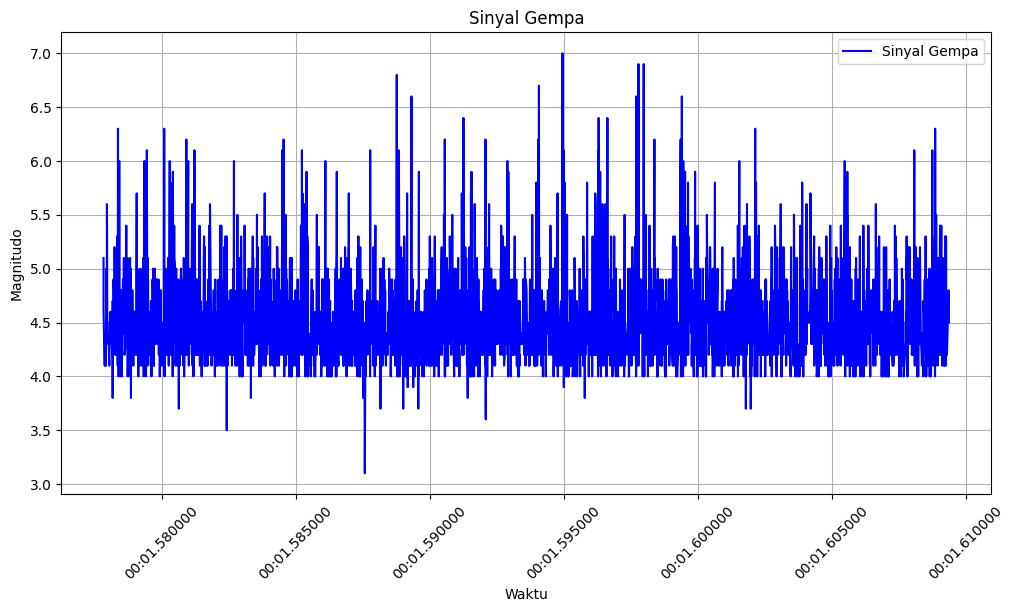

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Visualisasi
plt.figure(figsize=(12, 6))
plt.plot(df['Timestamp'], df['Mag'], label='Sinyal Gempa', color='b')
plt.title('Sinyal Gempa')
plt.xlabel('Waktu')
plt.ylabel('Magnitudo')
plt.xticks(rotation=45)  # Agar label waktu lebih terbaca
plt.grid(True)
plt.legend()
plt.show()

#**FILTERING SINYAL**

In [ ]:
pip install PyWavelets

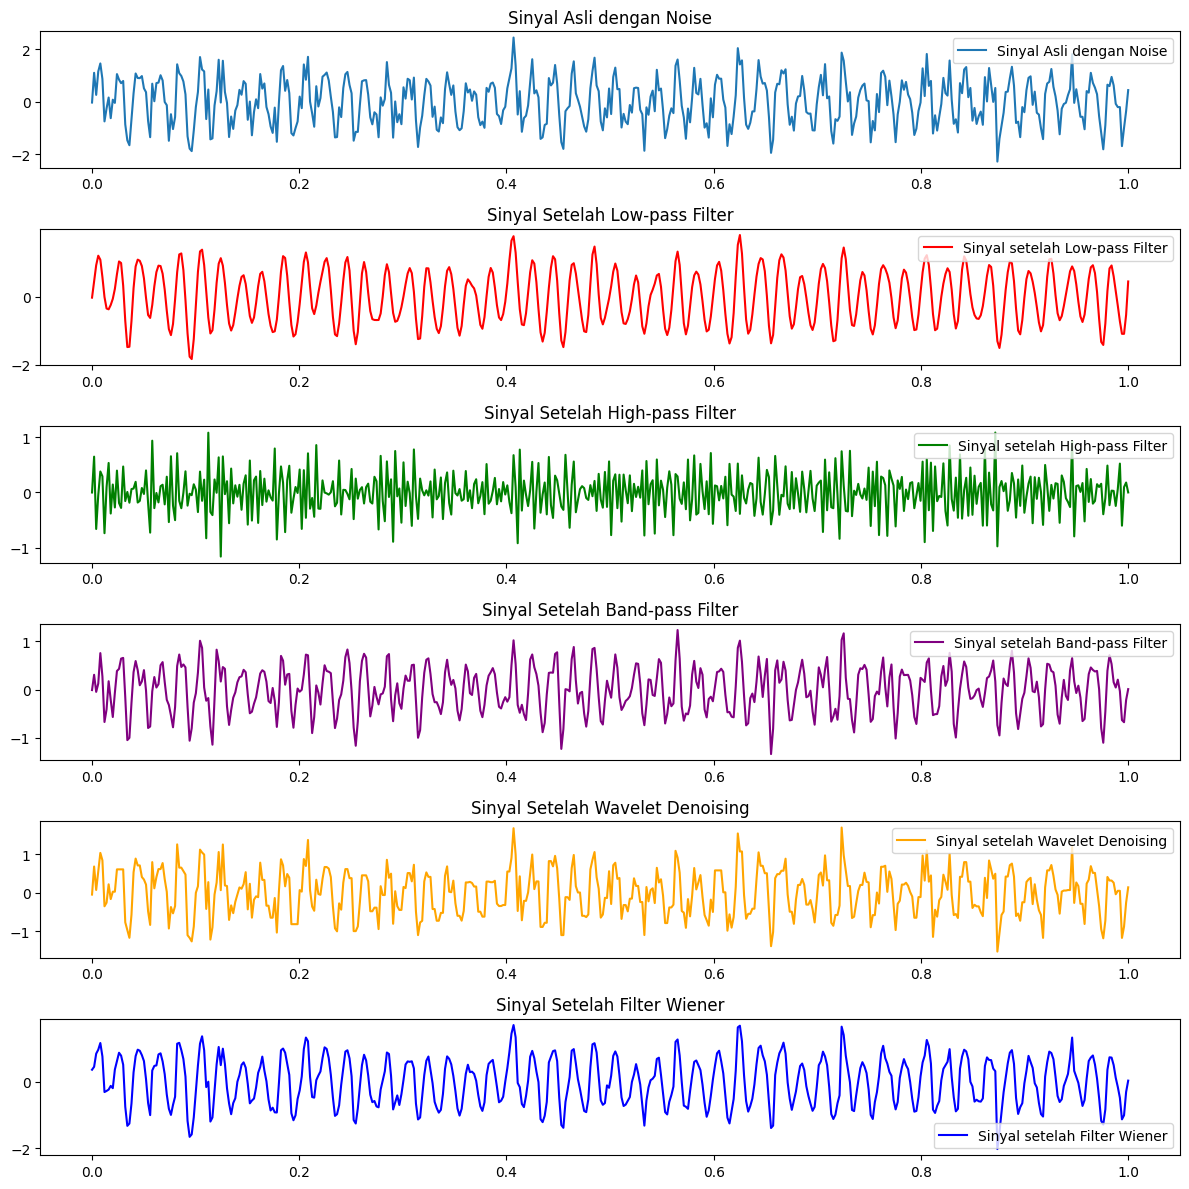

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, wiener
import pywt

# Fungsi untuk membuat filter low-pass
def butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

# Fungsi untuk membuat filter high-pass
def butter_highpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

# Fungsi untuk membuat filter band-pass
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

# Fungsi untuk menerapkan filter pada sinyal
def apply_filter(data, filter_type, **kwargs):
    b, a = filter_type(**kwargs)
    return filtfilt(b, a, data)

# Fungsi untuk wavelet denoising
def wavelet_denoising(data, wavelet='db1', level=6, threshold=0.2):
    coeffs = pywt.wavedec(data, wavelet, level=level)
    coeffs[1:] = [pywt.threshold(i, threshold*max(i)) for i in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet)

# Parameters
fs = 500  # Sampling frequency
t = np.linspace(0, 1.0, fs)  # Time vector
signal = np.sin(2 * np.pi * 50 * t) + 0.5 * np.random.randn(t.size)  # Sinusoidal signal with noise

# Filter Parameters
lowcut = 50  # Low-pass cutoff frequency
highcut = 150  # High-pass cutoff frequency
cutoff = 100  # Low-cut frequency for low-pass and high-pass

# Apply filters
low_pass_signal = apply_filter(signal, butter_lowpass, cutoff=cutoff, fs=fs)
high_pass_signal = apply_filter(signal, butter_highpass, cutoff=cutoff, fs=fs)
band_pass_signal = apply_filter(signal, butter_bandpass, lowcut=lowcut, highcut=highcut, fs=fs)
wavelet_filtered_signal = wavelet_denoising(signal)

# Apply Wiener Filter
wiener_filtered_signal = wiener(signal)

# Plotting the comparison
plt.figure(figsize=(12, 12))

# Original Signal
plt.subplot(6, 1, 1)
plt.plot(t, signal, label='Sinyal Asli dengan Noise')
plt.title('Sinyal Asli dengan Noise')
plt.legend()

# Low-pass Filtered Signal
plt.subplot(6, 1, 2)
plt.plot(t, low_pass_signal, label='Sinyal setelah Low-pass Filter', color='red')
plt.title('Sinyal Setelah Low-pass Filter')
plt.legend()

# High-pass Filtered Signal
plt.subplot(6, 1, 3)
plt.plot(t, high_pass_signal, label='Sinyal setelah High-pass Filter', color='green')
plt.title('Sinyal Setelah High-pass Filter')
plt.legend()

# Band-pass Filtered Signal
plt.subplot(6, 1, 4)
plt.plot(t, band_pass_signal, label='Sinyal setelah Band-pass Filter', color='purple')
plt.title('Sinyal Setelah Band-pass Filter')
plt.legend()

# Wavelet Denoised Signal
plt.subplot(6, 1, 5)
plt.plot(t, wavelet_filtered_signal, label='Sinyal setelah Wavelet Denoising', color='orange')
plt.title('Sinyal Setelah Wavelet Denoising')
plt.legend()

# Wiener Filtered Signal
plt.subplot(6, 1, 6)
plt.plot(t, wiener_filtered_signal, label='Sinyal setelah Filter Wiener', color='blue')
plt.title('Sinyal Setelah Filter Wiener')
plt.legend()

plt.tight_layout()
plt.show()


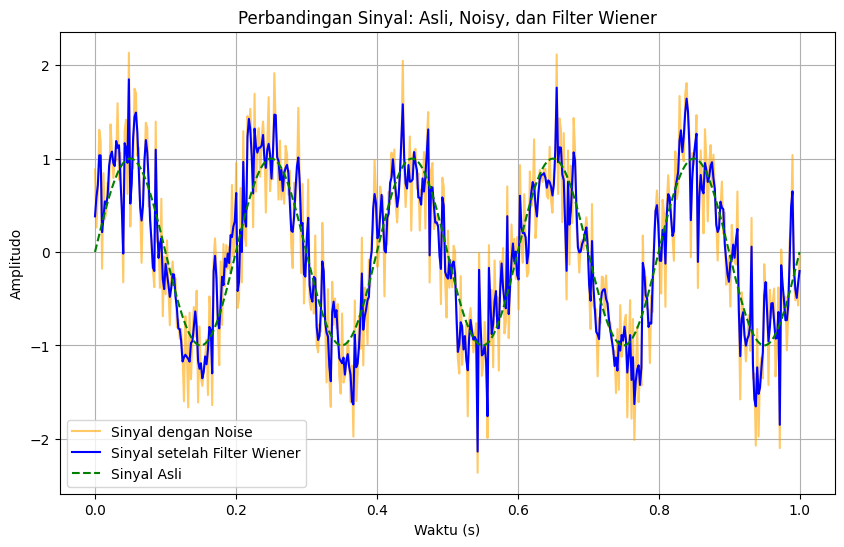

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import wiener

# Membuat sinyal asli dengan noise
np.random.seed(0)
t = np.linspace(0, 1, 500)
original_signal = np.sin(2 * np.pi * 5 * t)  # Sinyal sinus frekuensi 5 Hz
noise = np.random.normal(0, 0.5, t.shape)
noisy_signal = original_signal + noise

# Menggunakan Filter Wiener
filtered_signal = wiener(noisy_signal)

# Plot hasilnya
plt.figure(figsize=(10, 6))
plt.plot(t, noisy_signal, label='Sinyal dengan Noise', alpha=0.6, color='orange')
plt.plot(t, filtered_signal, label='Sinyal setelah Filter Wiener', color='blue')
plt.plot(t, original_signal, label='Sinyal Asli', color='green', linestyle='--')
plt.title('Perbandingan Sinyal: Asli, Noisy, dan Filter Wiener')
plt.xlabel('Waktu (s)')
plt.ylabel('Amplitudo')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Baca dataset
df = pd.read_csv('/content/dataset_cleaning')

# Tambahkan kolom sinyal sintetik
np.random.seed(0)
df['Signal'] = [','.join(map(str, np.random.normal(0, 1, 500))) for _ in range(len(df))]

# Simpan dataset baru dengan kolom 'Signal'
df.to_csv('dataset_sinyal', index=False)


In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import wiener

# Membaca data dari file CSV
data_path = '/content/dataset_sinyal'  # Ganti dengan nama file Anda
df = pd.read_csv(data_path)

# Pastikan kolom sinyal ada dalam dataset (misalnya 'Signal')
if 'Signal' in df.columns:

    # Terapkan Filter Wiener pada setiap nilai di kolom 'Signal'
    df['Filtered_Signal'] = df['Signal'].apply(lambda x: wiener(np.fromstring(x, sep=',')) if isinstance(x, str) else np.nan)

    # Konversi hasil kembali menjadi string untuk penyimpanan
    def convert_to_string(arr):
        return ','.join(map(str, arr)) if isinstance(arr, np.ndarray) else ''

df['Filtered_Signal'] = df['Filtered_Signal'].apply(convert_to_string)

# Simpan dataset baru dengan kolom 'Signal'
df.to_csv('dataset_sinyal_filter', index=False)

df.head()

,Year,Month,Day,Time,Lat,Lon,Depth,Mag,Region,Timestamp,Signal,Filtered_Signal
0,2020,12,30,23:03:00,5.1231,125.2581,54.1,4.6,"38 Km Sw Of Sarangani, Philippines",1609369380,"1.764052345967664,0.4001572083672233,0.9787379...","0.7214031847782958,1.047649179480209,1.2065961..."
1,2020,12,30,21:27:32,7.6359,126.9172,53.3,4.6,"40 Km E Of Baganga, Philippines",1609363652,"0.38273243001226814,-0.03424228053195387,1.096...","0.11616338316010476,0.48161233171537093,0.2759..."
2,2020,12,30,20:29:33,-6.6907,127.4441,393.4,4.5,"208 Km Nne Of Lospalos, Timor Leste",1609360173,"0.555962679709798,0.8924738873315303,-0.422314...","0.48281218901377604,0.3420405809720191,0.19162..."
3,2020,12,30,19:36:05,-6.8738,147.6965,68.4,4.5,"38 Km Ssw Of Finschhafen, Papua New Guinea",1609356965,"0.013239767667533552,-0.12194492760027727,0.33...","-0.03623505331091457,0.07678469866989557,-0.12..."
4,2020,12,30,19:10:20,-2.3988,127.4859,16.4,4.8,"163 Km Nnw Of Ambon, Indonesia",1609355420,"-1.5329210534301279,-1.7119701640942213,0.0461...","-1.0872611820360656,-1.1087852545295402,-0.874..."


#**KATEGORI DEPTH DAN MAG**

In [ ]:
data_path = '/content/dataset_sinyal_filter'
df = pd.read_csv(data_path)

def categorize_depth(depth):
    if depth < 70:
        return 'Shallow'
    elif 70 <= depth <= 300:
        return 'Intermediate'
    else:
        return 'Deep'

df['Depth_Category'] = df['Depth'].apply(categorize_depth)

In [ ]:
def categorize_magnitude(mag):
    if mag < 4.0:
        return 'Minor'
    elif 4.0 <= mag < 6.0:
        return 'Moderate'
    elif 6.0 <= mag < 7.0:
        return 'Strong'
    elif 7.0 <= mag < 8.0:
        return 'Major'
    else:
        return 'Great'

df['Magnitude_Category'] = df['Mag'].apply(categorize_magnitude)

df.to_csv('dataset_kategori_mag', index=False)

df

,Year,Month,Day,Time,Lat,Lon,Depth,Mag,Region,Timestamp,Signal,Filtered_Signal,Depth_Category,Magnitude_Category
0,2020,12,30,23:03:00,5.1231,125.2581,54.1,4.6,"38 Km Sw Of Sarangani, Philippines",1609369380,"1.764052345967664,0.4001572083672233,0.9787379...","0.7214031847782958,1.047649179480209,1.2065961...",Shallow,Moderate
1,2020,12,30,21:27:32,7.6359,126.9172,53.3,4.6,"40 Km E Of Baganga, Philippines",1609363652,"0.38273243001226814,-0.03424228053195387,1.096...","0.11616338316010476,0.48161233171537093,0.2759...",Shallow,Moderate
2,2020,12,30,20:29:33,-6.6907,127.4441,393.4,4.5,"208 Km Nne Of Lospalos, Timor Leste",1609360173,"0.555962679709798,0.8924738873315303,-0.422314...","0.48281218901377604,0.3420405809720191,0.19162...",Deep,Moderate
3,2020,12,30,19:36:05,-6.8738,147.6965,68.4,4.5,"38 Km Ssw Of Finschhafen, Papua New Guinea",1609356965,"0.013239767667533552,-0.12194492760027727,0.33...","-0.03623505331091457,0.07678469866989557,-0.12...",Shallow,Moderate
4,2020,12,30,19:10:20,-2.3988,127.4859,16.4,4.8,"163 Km Nnw Of Ambon, Indonesia",1609355420,"-1.5329210534301279,-1.7119701640942213,0.0461...","-1.0872611820360656,-1.1087852545295402,-0.874...",Shallow,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4044,2020,1,1,12:28:34,0.1936,121.5572,141.3,4.1,"38Km S Of Lemito, Indonesia",1577881714,"-0.37377193283273047,-0.11063549122678361,0.49...","-0.16146914135317136,0.004587529297728062,0.35...",Intermediate,Moderate
4045,2020,1,1,06:01:14,-6.7009,129.7667,155.1,4.4,"219Km Nw Of Saumlaki, Indonesia",1577858474,"1.3572581727642465,-0.6372684220994225,-0.7533...","0.23999658355494136,-0.16101558419197642,-0.12...",Intermediate,Moderate
4046,2020,1,1,04:38:07,2.0047,126.7211,51.0,4.4,"146Km Wnw Of Tobelo, Indonesia",1577853487,"-1.8717359577795445,-0.6366683548500742,-1.976...","-0.8361347708765395,-1.4951143096816972,-0.945...",Shallow,Moderate
4047,2020,1,1,00:35:48,-5.3373,152.6003,32.9,4.6,"107Km Ssw Of Taron, Papua New Guinea",1577838948,"1.1024208147964933,0.45747818531038464,-0.0084...","0.5199663333689594,0.5171440747117549,0.041011...",Shallow,Moderate


In [ ]:
df['Magnitude_Category'].value_counts()

,count
Magnitude_Category,
Moderate,3986
Strong,44
Minor,18
Major,1


#**VISUALISASI KATEGORI**

<ipython-input-131-91744b102b33>:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
<ipython-input-131-91744b102b33>:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  moderate_data_resampled = moderate_data.set_index('Time').resample('10T')['Mag'].mean().reset_index()
<ipython-input-131-91744b102b33>:41: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  minor_data_resampled = minor_data.set_index('Time').resample('10T')['Mag'].mean().reset_index()
<ipython-input-131-91744b102b33>:42: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  strong_data_resampled = strong_data.set_index('Time').resample('10T')['Mag'].mean().reset_index()
<ipython

Moderate Data: 3986 records
Minor Data: 18 records
Strong Data: 44 records
Major Data: 1 records

Time range for each category:
Moderate Time Range: 2025-01-01 00:00:07 to 2025-01-01 23:59:15
Minor Time Range: 2025-01-01 01:02:49 to 2025-01-01 23:58:31
Strong Time Range: 2025-01-01 00:03:48 to 2025-01-01 23:43:41
Major Time Range: 2025-01-01 02:50:22 to 2025-01-01 02:50:22

Mag Range for each category:
Moderate Mag Range: 4.0 to 5.9
Minor Mag Range: 3.1 to 3.9
Strong Mag Range: 6.0 to 6.9
Major Mag Range: 7.0 to 7.0


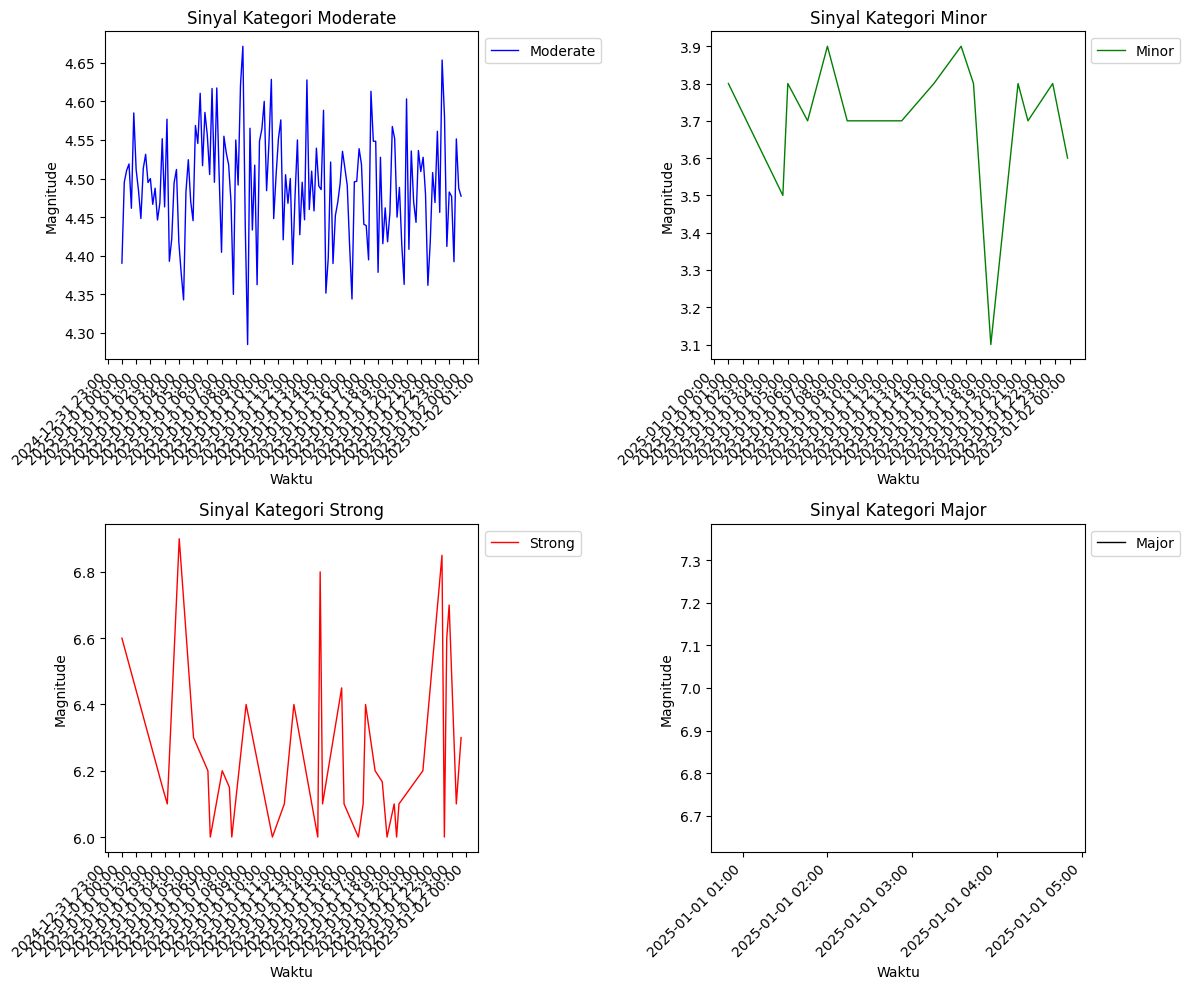

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file into a DataFrame
df = pd.read_csv('/content/dataset_kategori_mag')

# Pastikan 'Time' dalam format datetime
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

# Pastikan 'Mag' adalah numerik
df['Mag'] = pd.to_numeric(df['Mag'], errors='coerce')

# Filter data berdasarkan kategori 'Magnitude_Category'
moderate_data = df[df['Magnitude_Category'] == 'Moderate']
minor_data = df[df['Magnitude_Category'] == 'Minor']
strong_data = df[df['Magnitude_Category'] == 'Strong']
major_data = df[df['Magnitude_Category'] == 'Major']

# Cek data setelah filter
print(f"Moderate Data: {moderate_data.shape[0]} records")
print(f"Minor Data: {minor_data.shape[0]} records")
print(f"Strong Data: {strong_data.shape[0]} records")
print(f"Major Data: {major_data.shape[0]} records")

# Cek range waktu untuk memastikan tidak ada waktu yang ekstrem
print("\nTime range for each category:")
print(f"Moderate Time Range: {moderate_data['Time'].min()} to {moderate_data['Time'].max()}")
print(f"Minor Time Range: {minor_data['Time'].min()} to {minor_data['Time'].max()}")
print(f"Strong Time Range: {strong_data['Time'].min()} to {strong_data['Time'].max()}")
print(f"Major Time Range: {major_data['Time'].min()} to {major_data['Time'].max()}")

# Cek juga rentang nilai Mag
print("\nMag Range for each category:")
print(f"Moderate Mag Range: {moderate_data['Mag'].min()} to {moderate_data['Mag'].max()}")
print(f"Minor Mag Range: {minor_data['Mag'].min()} to {minor_data['Mag'].max()}")
print(f"Strong Mag Range: {strong_data['Mag'].min()} to {strong_data['Mag'].max()}")
print(f"Major Mag Range: {major_data['Mag'].min()} to {major_data['Mag'].max()}")

# Resampling, mengambil data setiap interval waktu tertentu (misalnya, per 10 menit) hanya pada kolom 'Mag'
moderate_data_resampled = moderate_data.set_index('Time').resample('10T')['Mag'].mean().reset_index()
minor_data_resampled = minor_data.set_index('Time').resample('10T')['Mag'].mean().reset_index()
strong_data_resampled = strong_data.set_index('Time').resample('10T')['Mag'].mean().reset_index()
major_data_resampled = major_data.set_index('Time').resample('5T')['Mag'].mean().reset_index()

# Interpolasi untuk mengisi nilai yang hilang
moderate_data_resampled['Mag'] = moderate_data_resampled['Mag'].interpolate(method='linear')
minor_data_resampled['Mag'] = minor_data_resampled['Mag'].interpolate(method='linear')
strong_data_resampled['Mag'] = strong_data_resampled['Mag'].interpolate(method='linear')
major_data_resampled['Mag'] = major_data_resampled['Mag'].interpolate(method='linear')

# Buat grafik untuk setiap kategori
plt.figure(figsize=(12, 10))  # Menyesuaikan ukuran figure untuk 4 subplots

# Subplot untuk Moderate
plt.subplot(2, 2, 1)
plt.plot(moderate_data_resampled['Time'], moderate_data_resampled['Mag'], label='Moderate', color='blue', linewidth=1)
plt.title('Sinyal Kategori Moderate')
plt.xlabel('Waktu')
plt.ylabel('Magnitude')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Subplot untuk Minor
plt.subplot(2, 2, 2)
plt.plot(minor_data_resampled['Time'], minor_data_resampled['Mag'], label='Minor', color='green', linewidth=1)
plt.title('Sinyal Kategori Minor')
plt.xlabel('Waktu')
plt.ylabel('Magnitude')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Subplot untuk Strong
plt.subplot(2, 2, 3)
plt.plot(strong_data_resampled['Time'], strong_data_resampled['Mag'], label='Strong', color='red', linewidth=1)
plt.title('Sinyal Kategori Strong')
plt.xlabel('Waktu')
plt.ylabel('Magnitude')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Subplot untuk Major
plt.subplot(2, 2, 4)
plt.plot(major_data_resampled['Time'], major_data_resampled['Mag'], label='Major', color='black', linewidth=1)
plt.title('Sinyal Kategori Major')
plt.xlabel('Waktu')
plt.ylabel('Magnitude')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Format waktu untuk setiap sumbu X agar lebih mudah dibaca
for ax in plt.gcf().get_axes():
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H:%M'))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.HourLocator(interval=1))  # Sesuaikan interval jika perlu
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Display all the plots
plt.tight_layout()
plt.show()


<ipython-input-132-987bafa50a10>:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])
<ipython-input-132-987bafa50a10>:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_earthquake = df.resample('H', on='Time').size()


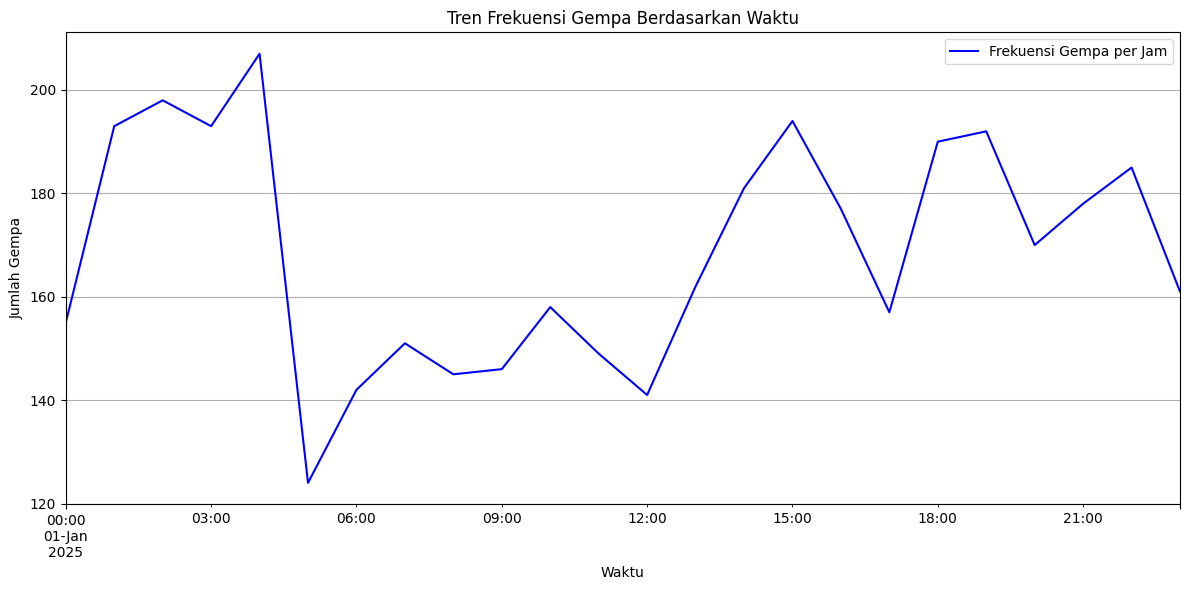

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data gempa dengan kolom 'Time' dan 'Mag'
df = pd.read_csv('/content/dataset_kategori_mag')

# Pastikan kolom waktu dalam format datetime
df['Time'] = pd.to_datetime(df['Time'])

# Resample data untuk menghitung jumlah gempa per jam
hourly_earthquake = df.resample('H', on='Time').size()

# Plot tren gempa per jam
plt.figure(figsize=(12, 6))
hourly_earthquake.plot(color='blue', label='Frekuensi Gempa per Jam')
plt.title('Tren Frekuensi Gempa Berdasarkan Waktu')
plt.xlabel('Waktu')
plt.ylabel('Jumlah Gempa')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#**ANALISIS STFT**

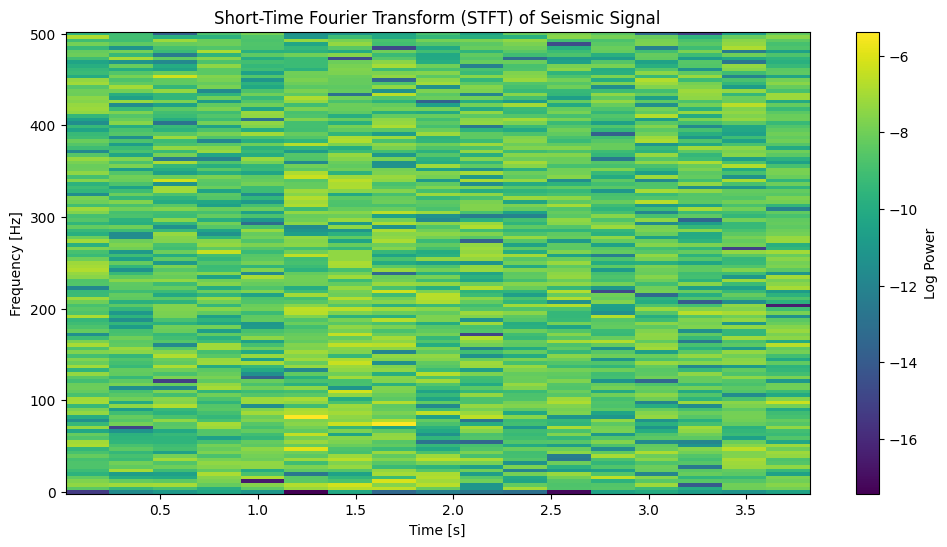

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

signal = df['Mag'].values  # atau kolom yang sesuai

# Menggunakan spectrogram untuk STFT
f, t, Sxx = spectrogram(signal, fs=1000)  # fs adalah sampling rate (misalnya 1000 Hz)

# Visualisasi
plt.figure(figsize=(12, 6))
plt.pcolormesh(t, f, np.log(Sxx), shading='auto')  # log untuk skala yang lebih baik
plt.title('Short-Time Fourier Transform (STFT) of Seismic Signal')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.colorbar(label='Log Power')
plt.show()

#berguna untuk melihat bagaimana frekuensi sinyal berubah seiring waktu.

#**PEMBAGIAN WILAYAH GEMPA**

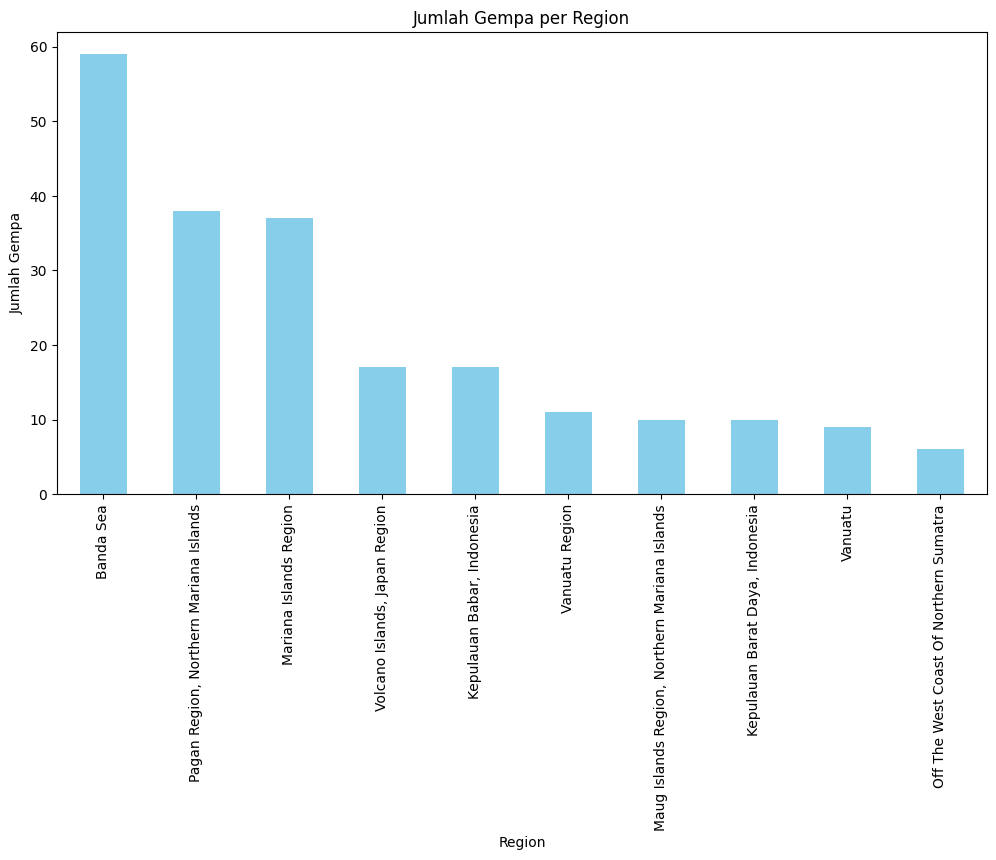

In [ ]:
# Data gempa dengan kolom 'Time' dan 'Mag'
df = pd.read_csv('/content/dataset_kategori_mag')

region_counts = df['Region'].value_counts()
region_counts.head(10).plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Jumlah Gempa per Region')
plt.xlabel('Region')
plt.ylabel('Jumlah Gempa')
plt.show()

#**KERUSAKAN GEMPA DAN PERINGATAN**

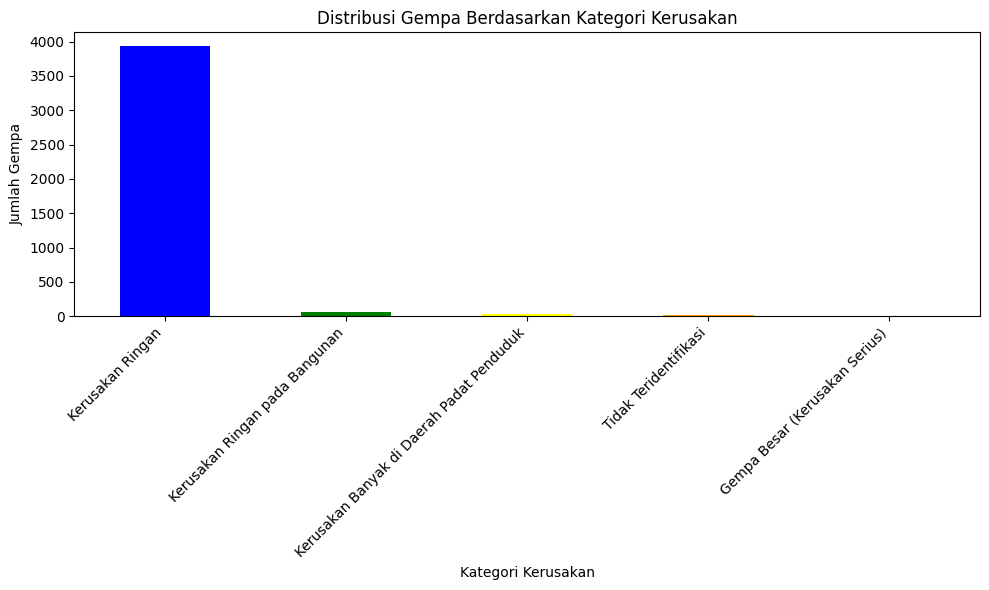


Jumlah Gempa Berdasarkan Kategori Kerusakan:
- Kerusakan Ringan: 3938 gempa
- Kerusakan Ringan pada Bangunan: 66 gempa
- Kerusakan Banyak di Daerah Padat Penduduk: 33 gempa
- Tidak Teridentifikasi: 11 gempa
- Gempa Besar (Kerusakan Serius): 1 gempa


In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt

# Data contoh (pastikan Anda memiliki data dalam format yang sesuai)
df = pd.read_csv('/content/dataset_kategori_mag')  # Ganti dengan nama file Anda

# Klasifikasi kerusakan berdasarkan magnitudo
def classify_damage(mag):
    if mag >= 8.0:
        return 'Gempa Besar (Menghancurkan Wilayah Pusatnya)'
    elif 7.0 <= mag < 8.0:
        return 'Gempa Besar (Kerusakan Serius)'
    elif 6.1 <= mag < 7.0:
        return 'Kerusakan Banyak di Daerah Padat Penduduk'
    elif 5.5 <= mag < 6.0:
        return 'Kerusakan Ringan pada Bangunan'
    elif 2.5 <= mag < 5.5:
        return 'Kerusakan Ringan'
    else:
        return 'Tidak Teridentifikasi'

# Menambahkan kolom klasifikasi kerusakan pada DataFrame
df['Damage Category'] = df['Mag'].apply(classify_damage)

# Menampilkan grafik distribusi gempa berdasarkan kategori kerusakan
damage_counts = df['Damage Category'].value_counts()

# Visualisasi grafik kategori kerusakan
plt.figure(figsize=(10, 6))
damage_counts.plot(kind='bar', color=['blue', 'green', 'yellow', 'orange', 'red'])
plt.title('Distribusi Gempa Berdasarkan Kategori Kerusakan')
plt.xlabel('Kategori Kerusakan')
plt.ylabel('Jumlah Gempa')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print jumlah gempa untuk setiap kategori
print("\nJumlah Gempa Berdasarkan Kategori Kerusakan:")
for category, count in damage_counts.items():
    print(f"- {category}: {count} gempa")

In [ ]:
import numpy as np
import pandas as pd

# Pastikan DataFrame sudah dimuat dengan benar
df = pd.read_csv('/content/dataset_kategori_mag')

# Pastikan kolom 'Time' sudah dalam format datetime
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

# Pastikan kolom 'Mag' dan 'Depth' adalah numerik
df['Mag'] = pd.to_numeric(df['Mag'], errors='coerce')
df['Depth'] = pd.to_numeric(df['Depth'], errors='coerce')

# Tambahkan kolom 'Risk Score' berdasarkan rumus yang diberikan
df['Risk Score'] = (df['Mag'] * df['Depth']) / (df['Time'].dt.hour + 1)  # Menambahkan +1 untuk menghindari pembagian nol

# Kategorikan 'Risk Score' menjadi kategori
df['Risk Category'] = pd.cut(
    df['Risk Score'],
    bins=[0, 50, 100, 200, np.inf],
    labels=['Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']
)

# Menampilkan data untuk memverifikasi hasil
print(df[['Mag', 'Depth', 'Risk Score', 'Risk Category']].head())


   Mag  Depth  Risk Score Risk Category
0  4.6   54.1   10.369167        Rendah
1  4.6   53.3   11.144545        Rendah
2  4.5  393.4   84.300000        Sedang
3  4.5   68.4   15.390000        Rendah
4  4.8   16.4    3.936000        Rendah


<ipython-input-136-9adf7fe98def>:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce')


In [ ]:
# Fungsi peringatan berdasarkan kategori risiko
def alert_system(row):
    if row['Risk Category'] == 'Sangat Tinggi':
        return "ALERT: Evakuasi segera!"
    elif row['Risk Category'] == 'Tinggi':
        return "WARNING: Bersiaplah untuk evakuasi."
    elif row['Risk Category'] == 'Sedang':
        return "INFO: Tetap waspada."
    else:
        return "AMAN: Tidak ada bahaya signifikan."

# Tambahkan kolom 'Alert' berdasarkan fungsi peringatan
df['Alert'] = df.apply(alert_system, axis=1)

# Menampilkan data dengan kolom Alert yang baru
print(df[['Mag', 'Depth', 'Risk Score', 'Risk Category', 'Alert']])

df.to_csv('dataset_peringatan', index=False)


      Mag  Depth  Risk Score  Risk Category  \
0     4.6   54.1   10.369167         Rendah   
1     4.6   53.3   11.144545         Rendah   
2     4.5  393.4   84.300000         Sedang   
3     4.5   68.4   15.390000         Rendah   
4     4.8   16.4    3.936000         Rendah   
...   ...    ...         ...            ...   
4044  4.1  141.3   44.563846         Rendah   
4045  4.4  155.1   97.491429         Sedang   
4046  4.4   51.0   44.880000         Rendah   
4047  4.6   32.9  151.340000         Tinggi   
4048  5.1   40.2  205.020000  Sangat Tinggi   

                                    Alert  
0      AMAN: Tidak ada bahaya signifikan.  
1      AMAN: Tidak ada bahaya signifikan.  
2                    INFO: Tetap waspada.  
3      AMAN: Tidak ada bahaya signifikan.  
4      AMAN: Tidak ada bahaya signifikan.  
...                                   ...  
4044   AMAN: Tidak ada bahaya signifikan.  
4045                 INFO: Tetap waspada.  
4046   AMAN: Tidak ada bahaya signifika

#**VISUALISASI TITIK GEMPA**

In [ ]:
import pandas as pd
import folium

# Fungsi untuk menentukan warna gempa berdasarkan kategori kerusakan
def get_color(category):
    if category == 'Gempa Besar (Menghancurkan Wilayah Pusatnya)':
        return 'red'
    elif category == 'Gempa Besar (Kerusakan Serius)':
        return 'orange'
    elif category == 'Kerusakan Banyak di Daerah Padat Penduduk':
        return 'yellow'
    elif category == 'Kerusakan Ringan pada Bangunan':
        return 'green'
    elif category == 'Kerusakan Ringan':
        return 'white'
    else:
        return 'gray'

# Misalkan 'df' adalah DataFrame yang berisi data gempa (pastikan kolom 'Lat', 'Lon', 'Mag', 'Region', dan 'Depth' ada)
# Menambahkan kolom klasifikasi kerusakan dan warna gempa pada DataFrame
df['Damage Category'] = df['Mag'].apply(classify_damage)
df['Color'] = df['Damage Category'].apply(get_color)

# Buat peta dasar dengan tema OpenStreetMap (tema yang umum dan mudah dimuat)
m = folium.Map(location=[df['Lat'].mean(), df['Lon'].mean()], zoom_start=5, tiles="OpenStreetMap")

# Tambahkan marker untuk setiap gempa dengan kategori kerusakan
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=row['Mag'] * 2,  # Sesuaikan ukuran dengan Magnitudo
        color=row['Color'],
        fill=True,
        fill_opacity=0.6,
        popup=f"Region: {row['Region']}<br>Mag: {row['Mag']}<br>Depth: {row['Depth']} km<br>Damage Category: {row['Damage Category']}"
    ).add_to(m)

# Simpan peta sebagai HTML
m.save("earthquake_map.html")


In [ ]:
url = "/content/dataset_peringatan"
df = pd.read_csv(url)

df


# Pastikan kolom 'Time' dalam format datetime
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

# Menghapus tanggal, hanya menyisakan waktu
df['Time'] = df['Time'].dt.time

df.to_csv('dataset_final', index=False)

df

,Year,Month,Day,Time,Lat,Lon,Depth,Mag,Region,Timestamp,Signal,Filtered_Signal,Depth_Category,Magnitude_Category,Risk Score,Risk Category,Alert
0,2020,12,30,23:03:00,5.1231,125.2581,54.1,4.6,"38 Km Sw Of Sarangani, Philippines",1609369380,"1.764052345967664,0.4001572083672233,0.9787379...","0.7214031847782958,1.047649179480209,1.2065961...",Shallow,Moderate,10.369167,Rendah,AMAN: Tidak ada bahaya signifikan.
1,2020,12,30,21:27:32,7.6359,126.9172,53.3,4.6,"40 Km E Of Baganga, Philippines",1609363652,"0.38273243001226814,-0.03424228053195387,1.096...","0.11616338316010476,0.48161233171537093,0.2759...",Shallow,Moderate,11.144545,Rendah,AMAN: Tidak ada bahaya signifikan.
2,2020,12,30,20:29:33,-6.6907,127.4441,393.4,4.5,"208 Km Nne Of Lospalos, Timor Leste",1609360173,"0.555962679709798,0.8924738873315303,-0.422314...","0.48281218901377604,0.3420405809720191,0.19162...",Deep,Moderate,84.300000,Sedang,INFO: Tetap waspada.
3,2020,12,30,19:36:05,-6.8738,147.6965,68.4,4.5,"38 Km Ssw Of Finschhafen, Papua New Guinea",1609356965,"0.013239767667533552,-0.12194492760027727,0.33...","-0.03623505331091457,0.07678469866989557,-0.12...",Shallow,Moderate,15.390000,Rendah,AMAN: Tidak ada bahaya signifikan.
4,2020,12,30,19:10:20,-2.3988,127.4859,16.4,4.8,"163 Km Nnw Of Ambon, Indonesia",1609355420,"-1.5329210534301279,-1.7119701640942213,0.0461...","-1.0872611820360656,-1.1087852545295402,-0.874...",Shallow,Moderate,3.936000,Rendah,AMAN: Tidak ada bahaya signifikan.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4044,2020,1,1,12:28:34,0.1936,121.5572,141.3,4.1,"38Km S Of Lemito, Indonesia",1577881714,"-0.37377193283273047,-0.11063549122678361,0.49...","-0.16146914135317136,0.004587529297728062,0.35...",Intermediate,Moderate,44.563846,Rendah,AMAN: Tidak ada bahaya signifikan.
4045,2020,1,1,06:01:14,-6.7009,129.7667,155.1,4.4,"219Km Nw Of Saumlaki, Indonesia",1577858474,"1.3572581727642465,-0.6372684220994225,-0.7533...","0.23999658355494136,-0.16101558419197642,-0.12...",Intermediate,Moderate,97.491429,Sedang,INFO: Tetap waspada.
4046,2020,1,1,04:38:07,2.0047,126.7211,51.0,4.4,"146Km Wnw Of Tobelo, Indonesia",1577853487,"-1.8717359577795445,-0.6366683548500742,-1.976...","-0.8361347708765395,-1.4951143096816972,-0.945...",Shallow,Moderate,44.880000,Rendah,AMAN: Tidak ada bahaya signifikan.
4047,2020,1,1,00:35:48,-5.3373,152.6003,32.9,4.6,"107Km Ssw Of Taron, Papua New Guinea",1577838948,"1.1024208147964933,0.45747818531038464,-0.0084...","0.5199663333689594,0.5171440747117549,0.041011...",Shallow,Moderate,151.340000,Tinggi,WARNING: Bersiaplah untuk evakuasi.


In [ ]:
import pandas as pd

# Memuat data
df = pd.read_csv('/content/dataset_final')

# Meminta input dari pengguna
month = int(input("Masukkan bulan (1-12): "))
day = int(input("Masukkan hari (1-31): "))

# Filter data berdasarkan kolom 'Month' dan 'Day'
filtered_data = df[(df['Month'] == month) & (df['Day'] == day)]

# Urutkan data berdasarkan kolom 'Time'
filtered_data = filtered_data.sort_values(by='Time')

# Menampilkan jumlah gempa
num_earthquakes = filtered_data.shape[0]
print(f"\nJumlah gempa yang terjadi pada {month:02d}-{day:02d} adalah {num_earthquakes}.")

if num_earthquakes > 0:
    print("\nDetail gempa yang terjadi:")
    for idx, row in filtered_data.iterrows():
        print(
            f"- Waktu: {row['Time']}, Lokasi: {row['Region']}, "
            f"Magnitudo: {row['Mag']}, Kedalaman: {row['Depth']} km"
        )
else:
    print("\nTidak ada gempa yang tercatat pada tanggal tersebut.")


Masukkan bulan (1-12): 8
Masukkan hari (1-31): 7

Jumlah gempa yang terjadi pada 08-07 adalah 8.

Detail gempa yang terjadi (diurutkan berdasarkan waktu):
- Waktu: 01:29:37, Lokasi: 194 Km Ne Of Lospalos, Timor Leste, Magnitudo: 4.4, Kedalaman: 109.8 km
- Waktu: 03:00:39, Lokasi: 220 Km W Of Ambon, Indonesia, Magnitudo: 5.3, Kedalaman: 10.0 km
- Waktu: 03:24:25, Lokasi: 206 Km Sw Of Merizo Village, Guam, Magnitudo: 4.6, Kedalaman: 10.0 km
- Waktu: 06:30:48, Lokasi: 156 Km Wnw Of Tobelo, Indonesia, Magnitudo: 4.9, Kedalaman: 51.4 km
- Waktu: 11:41:40, Lokasi: 282 Km Ene Of Lospalos, Timor Leste, Magnitudo: 4.3, Kedalaman: 164.8 km
- Waktu: 15:13:48, Lokasi: 205 Km Sw Of Labuan, Indonesia, Magnitudo: 4.5, Kedalaman: 32.1 km
- Waktu: 16:08:44, Lokasi: 163 Km Nnw Of Likisá, Timor Leste, Magnitudo: 4.0, Kedalaman: 548.4 km
- Waktu: 17:49:46, Lokasi: 63 Km Sw Of Pagar Alam, Indonesia, Magnitudo: 4.2, Kedalaman: 64.5 km
